In [1]:
%load_ext autoreload
%autoreload 2
import os

# I believe this environment variable should be set before importing t
os.environ["PYt_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch as t
from transformers import AutoModelForCausalLM, AutoTokenizer
import argparse
import itertools
import random
import json
import torch.multiprocessing as mp
import time
import huggingface_hub
from datasets import config
from transformers import AutoTokenizer
import demo_config
from tqdm import tqdm
import matplotlib.pyplot as plt

# Kind of janky double importing dictionary_learning.dictionary_learning, but it works
# This is leftover from when dictionary_learning was a only used as a submodule
from dictionary_learning.dictionary_learning.utils import (
    hf_dataset_to_generator,
    hf_mixed_dataset_to_generator,
    hf_sequence_packing_dataset_to_generator,
)
from dictionary_learning.dictionary_learning.pytorch_buffer import ActivationBuffer
from dictionary_learning.dictionary_learning.evaluation import evaluate
from dictionary_learning.dictionary_learning.training import trainSAE
import dictionary_learning.dictionary_learning.utils as utils


if os.path.exists('/u/eboix/moe_distillation/sae_demo'):
    os.chdir('/u/eboix/moe_distillation/sae_demo')

In [2]:
sae_dir = '._saes_EleutherAI_pythia-70m-deduped_top_k/mlp_in_3/trainer_0/'
device = t.device('cuda' if t.cuda.is_available() else 'cpu')

# load config.json from sae_dir
config_path = os.path.join(sae_dir, 'config.json')
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = json.load(f)
else:
    assert(False), f'Config file not found at {config_path}'

model_name = config_data['trainer']['lm_name']
layer_idx = config_data['trainer']['layer']
io = config_data['buffer']['io']
dtype = t.float32

model = AutoModelForCausalLM.from_pretrained(
    model_name, device_map="auto", torch_dtype=dtype
)

model = utils.truncate_model(model, layer_idx)
model.eval()
model = model.to(device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
submodule = utils.get_submodule(model, layer_idx).mlp
submodule = submodule.to(device)
print('Model loaded:', model_name)

generator = hf_dataset_to_generator("monology/pile-uncopyrighted", 
    data_files={"validation": "val.jsonl.zst"},
    split="validation",)

activation_dim = config_data["trainer"]["activation_dim"]

activation_buffer = ActivationBuffer(
    generator,
    model,
    submodule,
    n_ctxs=config_data['buffer']['n_ctxs'],
    ctx_len=config_data['buffer']['ctx_len'],
    refresh_batch_size=config_data['buffer']['refresh_batch_size'],
    out_batch_size=config_data['buffer']['out_batch_size'],
    io=io,
    d_submodule=activation_dim,
    device=device,
)

print('Initialized activation buffer')


Model parameters before truncation: 70,426,624
Model parameters after truncation: 38,366,208
Model loaded: EleutherAI/pythia-70m-deduped
Initialized activation buffer


In [3]:
# create SparseMLP class, which has 3 layers
# the first layer is the input layer, the second layer is the sparse layer, and the third layer is the output layer
# the second layer has a topk activation
# the third layer has a gelu activation function
class SparseMLP(t.nn.Module):
    def __init__(self, d_in, d_out, dict_size, d_intermediate, k):
        super(SparseMLP, self).__init__()
        self.dict_size = dict_size
        self.encoder = t.nn.Linear(d_in, dict_size)
        self.layer1 = t.nn.Linear(dict_size, d_intermediate)
        self.layer2 = t.nn.Linear(d_intermediate, d_out)
        self.k = k

    def forward(self, x):
        x = self.encoder(x)
        topk_values, _ = t.topk(x.abs(), k=self.k, dim=-1)
        threshold = topk_values[..., -1].unsqueeze(-1)
        x = t.where(x.abs() >= threshold, x, t.zeros_like(x))
        x = self.layer1(x)
        x = t.nn.functional.gelu(x)
        x = self.layer2(x)
        return x

In [4]:
# Estimate variance of y_teacher
# first estimate mean
n_estimate_iters = 4
y_mean = t.zeros(activation_dim, device=device)
for _ in tqdm(range(n_estimate_iters)):
    x = next(activation_buffer)
    x = x.to(device)
    y_teacher = submodule(x)
    y_mean += y_teacher.mean(dim=0)
y_mean /= n_estimate_iters

y_variance = 0.0
for _ in tqdm(range(n_estimate_iters)):
    x = next(activation_buffer)
    x = x.to(device)
    y_teacher = submodule(x)
    y_variance += t.mean(t.mean((y_teacher - y_mean) ** 2, dim=0))
y_variance /= n_estimate_iters
y_variance = y_variance.item()
print('Variance in y', y_variance)


  0%|                                                                                                                                                                                                                                                                              | 0/4 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 266.06it/s]

Variance in y 0.17725706100463867


In [13]:
# Train SparseMLP student model to match the teacher model on the activation buffer
# inputs are x from activation_buffer, outputs are submodule(x)
# loss is MSE
# train with AdamW with learning rate decay and warmup
lr = 1e-3
num_train_tokens = 50_000_000
num_train_steps = num_train_tokens // config_data['buffer']['out_batch_size']
print(num_train_steps, 'training steps')
submodule.eval()

student_model = SparseMLP(
    d_in=activation_dim,
    d_out=activation_dim,
    dict_size=config_data['trainer']['dict_size'],
    d_intermediate=4*activation_dim,
    k=config_data['trainer']['k'],
)
student_model = student_model.to(device)

optimizer = t.optim.Adam(student_model.parameters(), lr=lr)
criterion = t.nn.MSELoss()
scheduler = t.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_train_steps, eta_min=0)
# Training loop
from tqdm import tqdm

student_model.train()
running_loss = 0.0
step_count = 0
pbar = tqdm(activation_buffer, total=num_train_steps)
for x in pbar:
    x = x.to(device)
    optimizer.zero_grad()
    with t.no_grad():
        y_teacher = submodule(x)
    y_student = student_model(x)
    loss = criterion(y_student, y_teacher)
    loss.backward()
    optimizer.step()
    
    # Update running loss
    running_loss += loss.item()
    step_count += 1
    
    current_lr = scheduler.get_last_lr()[0]
    frac_var_explained = 1 - (loss.item() / y_variance)
    pbar.set_postfix(loss=loss.item(), avg_loss=running_loss/step_count, lr=current_lr, frac_var_explained=frac_var_explained)

    scheduler.step()

24414 training steps


 45%|▍| 11089/24414 [11:37<13:58, 15.90it/s, avg_loss=0.0305, frac_var_explained=0.85, loss=0.0265, lr=0.000572


In [5]:
# load autoencoder from sae_file
from dictionary_learning.dictionary_learning.trainers.top_k import AutoEncoderTopK
ae_file = os.path.join(sae_dir, 'ae.pt')
autoencoder = AutoEncoderTopK.from_pretrained(ae_file)
autoencoder = autoencoder.to(device)
autoencoder.eval()
print('Autoencoder loaded from:', ae_file)

Autoencoder loaded from: ._saes_EleutherAI_pythia-70m-deduped_top_k/mlp_in_3/trainer_0/ae.pt


In [6]:
n_estimate_iters = 4
err = 0
with t.no_grad():
    for _ in tqdm(range(n_estimate_iters)):
        x = next(activation_buffer)
        x = x.to(device)
        x_recon = autoencoder(x)
        y_recon = submodule(x_recon)
        y_teacher = submodule(x)
        err += t.mean((y_recon - y_teacher)**2)
    err /= n_estimate_iters
print('Error in reconstruction:', err.item())
print('Fraction of variance explained by autoencoder:', 1 - (err.item() / y_variance))

  0%|                                                                                                                                                                                                                                                                              | 0/4 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 105.46it/s]

Error in reconstruction: 0.020468445494771004
Fraction of variance explained by autoencoder: 0.8845267693215597


In [7]:
autoencoder

AutoEncoderTopK(
  (decoder): Linear(in_features=16384, out_features=512, bias=False)
  (encoder): Linear(in_features=512, out_features=16384, bias=True)
)

In [8]:
class NaiveMoELowRankModel(t.nn.Module):
    def __init__(self, d, d_hidden, d_expert, m, k):
        super(NaiveMoELowRankModel, self).__init__()
        self.d = d
        self.d_expert = d_expert
        assert(d_expert == 1), "NaiveMoELowRankModel only supports d_expert = 1"
        self.m = m
        self.k = k
        self.experts1 = t.nn.Linear(d,m)
        self.experts2 = t.nn.Linear(m, d_hidden)
        self.fc2 = t.nn.Linear(d_hidden, d)

    def forward(self, x):
        x = self.experts1(x)  # Shape: [batch_size, m]
        # zero out all but the top-k entries of x
        top_k_values, top_k_indices = x.topk(self.k, dim=1)
        x = t.zeros_like(x)
        x.scatter_(1, top_k_indices, top_k_values)
        x = self.experts2(x)
        # nonlinear gelu activation
        x = t.nn.functional.gelu(x)
        # apply fc2 to get back to original dimension
        x = self.fc2(x)
        return x

In [9]:
autoencoder

AutoEncoderTopK(
  (decoder): Linear(in_features=16384, out_features=512, bias=False)
  (encoder): Linear(in_features=512, out_features=16384, bias=True)
)

In [10]:
naive_model = NaiveMoELowRankModel(activation_dim, 4*activation_dim, 1, 16384, 40)
naive_model = naive_model.to(device)
naive_model.experts1.weight.data = autoencoder.encoder.weight.data.clone()
naive_model.experts1.bias.data = autoencoder.encoder.bias.data.clone() - autoencoder.encoder.weight.data.clone() @ autoencoder.b_dec.data.clone()
naive_model.experts2.weight.data = submodule.dense_h_to_4h.weight.data.clone() @ autoencoder.decoder.weight.data.clone()
naive_model.experts2.bias.data = submodule.dense_h_to_4h.bias.data.clone() + submodule.dense_h_to_4h.weight.data.clone() @ autoencoder.b_dec.data.clone()
naive_model.fc2.weight.data = submodule.dense_4h_to_h.weight.data.clone()
naive_model.fc2.bias.data = submodule.dense_4h_to_h.bias.data.clone()
naive_model.eval()



NaiveMoELowRankModel(
  (experts1): Linear(in_features=512, out_features=16384, bias=True)
  (experts2): Linear(in_features=16384, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=512, bias=True)
)

In [11]:
submodule

GPTNeoXMLP(
  (dense_h_to_4h): Linear(in_features=512, out_features=2048, bias=True)
  (dense_4h_to_h): Linear(in_features=2048, out_features=512, bias=True)
  (act): GELUActivation()
)

In [12]:
n_estimate_iters = 4
err = 0
with t.no_grad():
    for _ in tqdm(range(n_estimate_iters)):
        x = next(activation_buffer)
        x = x.to(device)
        # y_recon = submodule(autoencoder(x))
        y_recon = naive_model(x)
        y_teacher = submodule(x)
        err += t.mean((y_recon - y_teacher)**2)
    err /= n_estimate_iters
print('Error in reconstruction:', err.item())
print('Fraction of variance explained by autoencoder:', 1 - (err.item() / y_variance))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 98.54it/s]

Error in reconstruction: 0.020666606724262238
Fraction of variance explained by autoencoder: 0.8834088379490767


In [13]:
naive_model

NaiveMoELowRankModel(
  (experts1): Linear(in_features=512, out_features=16384, bias=True)
  (experts2): Linear(in_features=16384, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=512, bias=True)
)

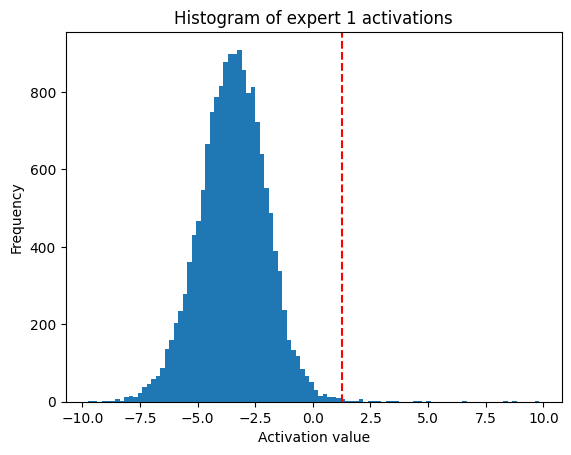

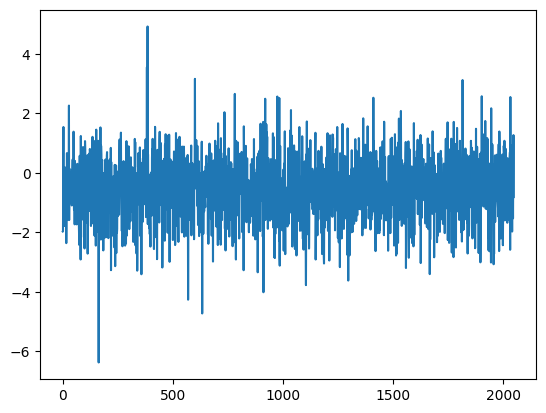

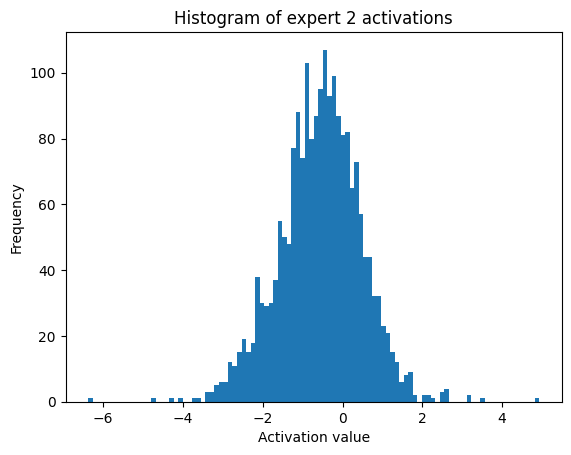

In [14]:
with t.no_grad():
    i = 4
    scores = naive_model.experts1(x)[i,:]
    threshold = t.min(t.topk(scores, k=autoencoder.k).values)
    plt.hist(scores.cpu().numpy(), bins=100)
    plt.axvline(threshold.item(), color='red', linestyle='--')
    plt.title('Histogram of expert 1 activations')
    plt.xlabel('Activation value')
    plt.ylabel('Frequency')
    plt.show()
    x_new = naive_model.experts1(x)  # Shape: [batch_size, m]
    # zero out all but the top-k entries of x
    top_k_values, top_k_indices = x_new.topk(naive_model.k, dim=1)
    x_new = t.zeros_like(x_new)
    x_new.scatter_(1, top_k_indices, top_k_values)
    x_new = naive_model.experts2(x_new)
    plt.plot(x_new.cpu().numpy()[i,:], label='Expert 2 output')
    plt.show()
    plt.hist(x_new.cpu().numpy()[i,:], bins=100)
    plt.title('Histogram of expert 2 activations')
    plt.xlabel('Activation value')
    plt.ylabel('Frequency')
    plt.show()

    


In [15]:
top_k_indices[i,:]

tensor([ 5993,  9893,  8553,  4154,   193,   107,  2782,  5946, 14706,  4302,
         8850,  5118, 11263, 11643, 10346, 11730, 13749,   584,  4484,  9614,
         6733,  3396,  1969, 15232, 12095,  7572,  3996,  8485,  8847, 12978,
         8028,  8131,  3237,  6583,  6126, 13941,  2789, 15056,  1723,  4500],
       device='cuda:0')

tensor([15.0781, 12.4725,  6.7224,  3.7378,  3.6528,  2.9908,  2.8846,  2.8336,
         2.3407,  2.2293,  2.0095,  1.9213,  1.8837,  1.8187,  1.7643,  1.7132,
         1.6328,  1.6059,  1.5942,  1.5148,  1.3683,  1.2970,  1.2469,  1.2135,
         1.1700,  1.1605,  1.1436,  1.1101,  1.0864,  1.0499,  0.9731,  0.9193,
         0.8877,  0.8790,  0.8785,  0.8169,  0.7490,  0.6973,  0.6820,  0.6745],
       device='cuda:0')
torch.Size([2048, 40])


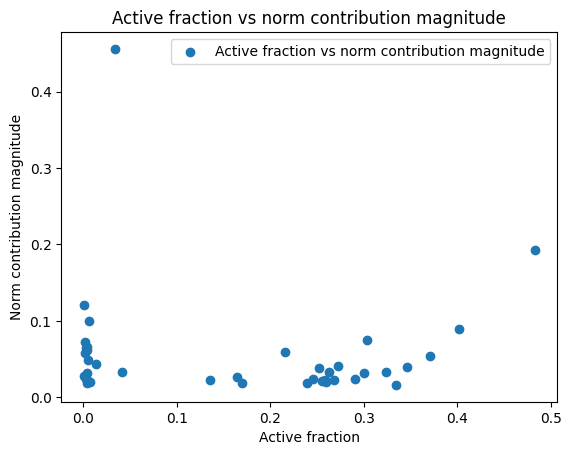

tensor([8.7886, 6.2880, 5.9549, 5.5282, 4.3377, 4.1628, 4.1431, 3.6652, 3.5240,
        3.5068, 3.3824, 2.8946, 2.7924, 2.7622, 2.6834, 2.5235, 2.3631, 2.3089,
        2.2448, 2.2127, 2.1220, 2.0186, 1.9995, 1.8907, 1.8862, 1.7861, 1.7344,
        1.7339, 1.6855, 1.6835, 1.6183, 1.6113, 1.5898, 1.5591, 1.4465, 1.4090,
        1.3971, 1.3709, 1.3591, 1.2961], device='cuda:0')
torch.Size([2048, 40])


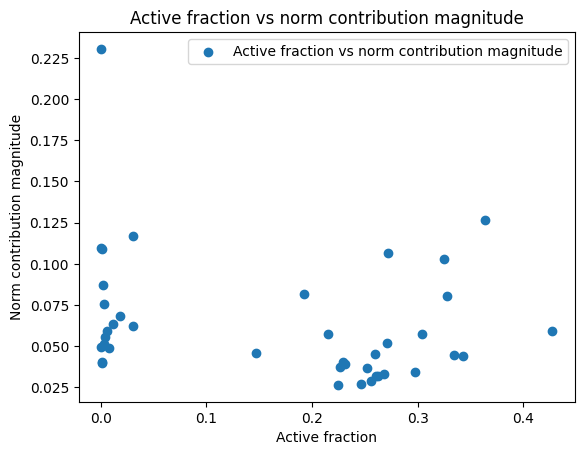

tensor([8.3895, 6.4493, 5.1924, 5.1382, 4.7108, 4.6696, 4.5877, 4.5370, 4.4008,
        3.8161, 3.7050, 3.5318, 3.1277, 2.9437, 2.8935, 2.6806, 2.4802, 2.4232,
        2.3024, 2.2913, 2.2215, 2.2042, 2.1796, 2.1383, 2.1081, 1.8442, 1.8160,
        1.7884, 1.7762, 1.7336, 1.6895, 1.6437, 1.5699, 1.5404, 1.4912, 1.4478,
        1.3964, 1.3303, 1.3253, 1.2889], device='cuda:0')
torch.Size([2048, 40])


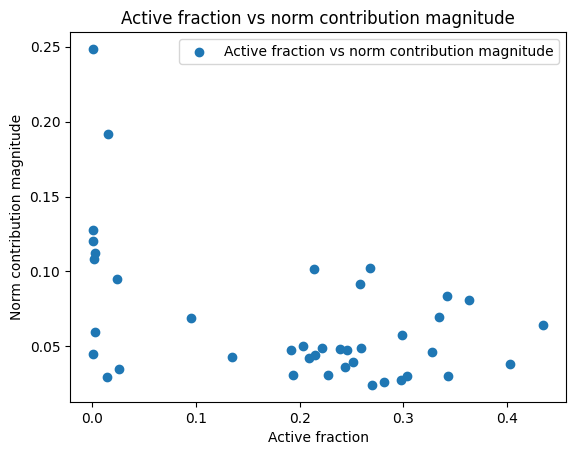

tensor([8.4907, 6.9057, 6.8190, 6.6759, 6.3977, 5.1344, 4.6818, 3.7919, 3.5491,
        3.5429, 3.4748, 3.2129, 2.9675, 2.8940, 2.5437, 2.4659, 2.4632, 2.4266,
        2.3586, 2.3250, 2.1077, 2.0764, 2.0596, 2.0392, 1.8440, 1.8028, 1.7351,
        1.5678, 1.5149, 1.4693, 1.4326, 1.4205, 1.4197, 1.4120, 1.3820, 1.3476,
        1.3397, 1.3203, 1.3124, 1.2949], device='cuda:0')
torch.Size([2048, 40])


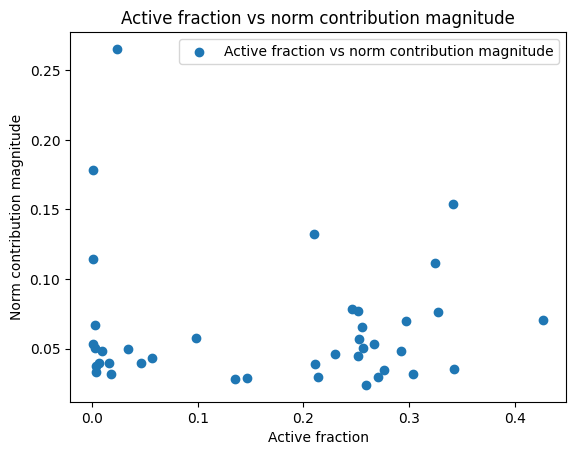

tensor([9.8171, 8.7231, 8.3554, 6.5372, 5.0437, 4.6044, 4.4549, 4.3677, 3.7086,
        3.6019, 3.5744, 3.4301, 3.2640, 3.1850, 2.8652, 2.5827, 2.4321, 2.4290,
        2.1682, 2.1508, 2.1439, 2.0836, 2.0803, 2.0788, 2.0343, 2.0336, 1.9346,
        1.9293, 1.9012, 1.7767, 1.7749, 1.6244, 1.4709, 1.3872, 1.3464, 1.3459,
        1.3457, 1.3431, 1.2713, 1.2699], device='cuda:0')
torch.Size([2048, 40])


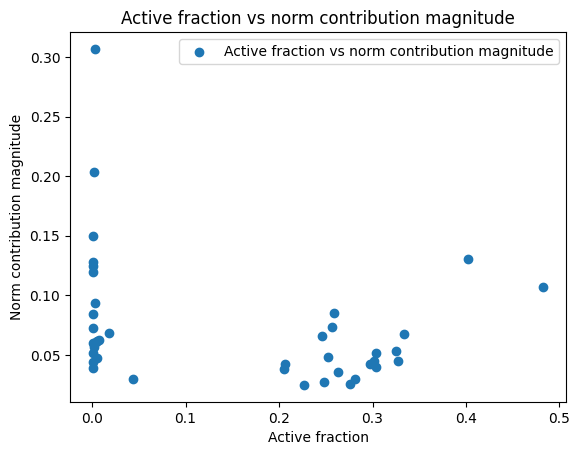

In [ ]:
import math
with t.no_grad():

    x_new = naive_model.experts1(x)  # Shape: [batch_size, m]
    # zero out all but the top-k entries of x
    top_k_values, top_k_indices = x_new.topk(naive_model.k, dim=1)
    x_new = t.zeros_like(x_new)
    x_new.scatter_(1, top_k_indices, top_k_values)
    frac_active = t.sum(x_new != 0, dim=0) / x_new.shape[0]\

    for i in range(5):

        second_layer_wts = naive_model.experts2.weight.data[:,top_k_indices[i,:]]
        second_layer_norms = t.norm(second_layer_wts, dim=0) / math.sqrt(second_layer_wts.shape[0])
        norm_contrib_magnitude = top_k_values[i,:] * second_layer_norms
        curr_active_frac = frac_active[top_k_indices[i,:]]
        # plt.hist(second_layer_norms.cpu().numpy(), label='Expert 2 norms')
        # plt.show()
        # plt.hist(norm_contrib_magnitude.cpu().numpy(), label='Norm contribution magnitude', bins=100, range=(0,1))
        # plt.show()
        plt.scatter(curr_active_frac.cpu().numpy(), norm_contrib_magnitude.cpu().numpy(), label='Active fraction vs norm contribution magnitude')
        plt.xlabel('Active fraction')
        plt.ylabel('Norm contribution magnitude')
        plt.title('Active fraction vs norm contribution magnitude')
        plt.legend()
        plt.show()
        
    # plt.plot(second_layer_wts[:,10].cpu().numpy(), label='Expert 2 weights')
    # plt.show()


    


In [ ]:
import math
with t.no_grad():

    x_new = naive_model.experts1(x)  # Shape: [batch_size, m]
    # zero out all but the top-k entries of x
    top_k_values, top_k_indices = x_new.topk(naive_model.k, dim=1)
    x_new = t.zeros_like(x_new)
    x_new.scatter_(1, top_k_indices, top_k_values)
    frac_active = t.sum(x_new != 0, dim=0) / x_new.shape[0]\

    for i in range(5):
        
        print(x_new[i,top_k_indices[i,:]])

        second_layer_wts = naive_model.experts2.weight.data[:,top_k_indices[i,:]]
        second_layer_norms = t.norm(second_layer_wts, dim=0) / math.sqrt(second_layer_wts.shape[0])
        norm_contrib_magnitude = top_k_values[i,:] * second_layer_norms
        curr_active_frac = frac_active[top_k_indices[i,:]]
        # # plt.hist(second_layer_norms.cpu().numpy(), label='Expert 2 norms')
        # # plt.show()
        # # plt.hist(norm_contrib_magnitude.cpu().numpy(), label='Norm contribution magnitude', bins=100, range=(0,1))
        # # plt.show()
        # plt.scatter(curr_active_frac.cpu().numpy(), norm_contrib_magnitude.cpu().numpy(), label='Active fraction vs norm contribution magnitude')
        # plt.xlabel('Active fraction')
        # plt.ylabel('Norm contribution magnitude')
        # plt.title('Active fraction vs norm contribution magnitude')
        # plt.legend()
        # plt.show()
        
    # plt.plot(second_layer_wts[:,10].cpu().numpy(), label='Expert 2 weights')
    # plt.show()


    


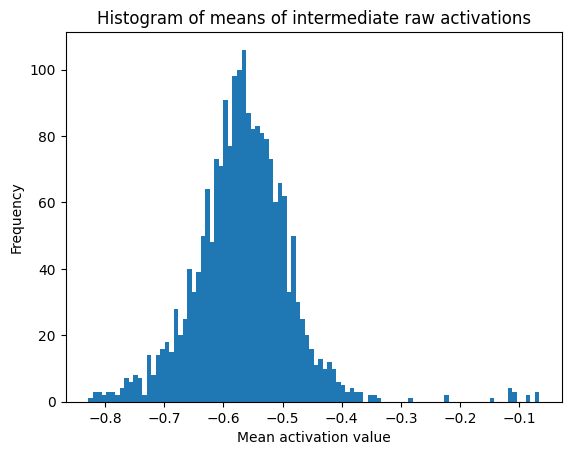

Mean and std of intermediate raw activations


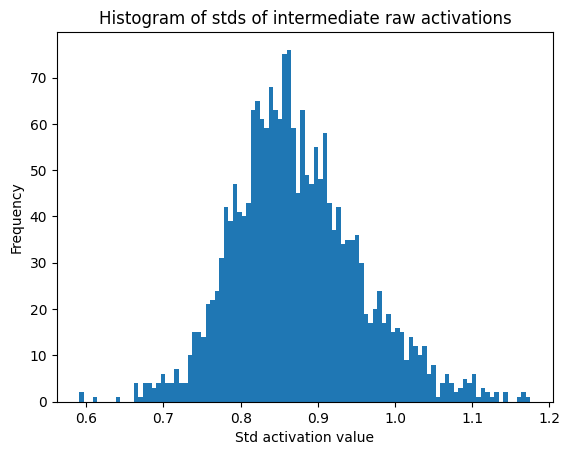

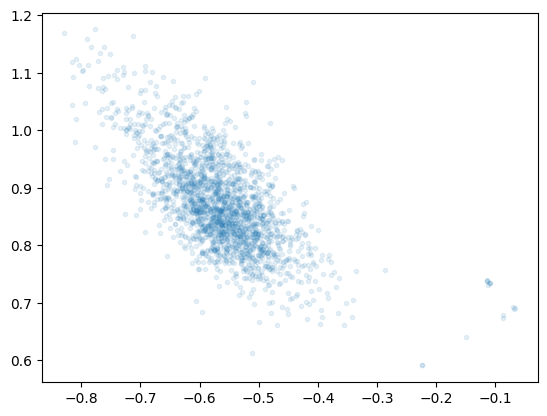

In [34]:
with t.no_grad():
    x_new = naive_model.experts1(x)  # Shape: [batch_size, m]
    # zero out all but the top-k entries of x
    top_k_values, top_k_indices = x_new.topk(naive_model.k, dim=1)
    x_new = t.zeros_like(x_new)
    x_new.scatter_(1, top_k_indices, top_k_values)
    x_new = naive_model.experts2(x_new)
    intermediate_raw = x_new
    means = t.mean(intermediate_raw, dim=1)
    stds = t.std(intermediate_raw, dim=1)
    plt.hist(means.cpu().numpy(), bins=100)
    plt.title('Histogram of means of intermediate raw activations')
    plt.xlabel('Mean activation value')
    plt.ylabel('Frequency')
    plt.show()
    print('Mean and std of intermediate raw activations')
    plt.hist(stds.cpu().numpy(), bins=100)
    plt.title('Histogram of stds of intermediate raw activations')
    plt.xlabel('Std activation value')
    plt.ylabel('Frequency')
    plt.show()
    plt.scatter(means.cpu().numpy(), stds.cpu().numpy(), marker='.', alpha=0.1)
    # print(means.mean().item(), means.std().item())
    # for i in range(10):
    #     print('Mean and std of intermediate raw activations for sample', i)
    #     print(t.mean(intermediate_raw[i,:]).item(), t.std(intermediate_raw[i,:]).item())
    #     # plt.hist(intermediate_raw[i,:].cpu().numpy(), bins=100)
    #     # plt.title('Histogram of intermediate raw activations')
    #     # plt.xlabel('Activation value')
    #     # plt.ylabel('Frequency')
    #     # plt.show()

In [ ]:
x = x[1:,:]

In [26]:
x.shape

torch.Size([2047, 512])

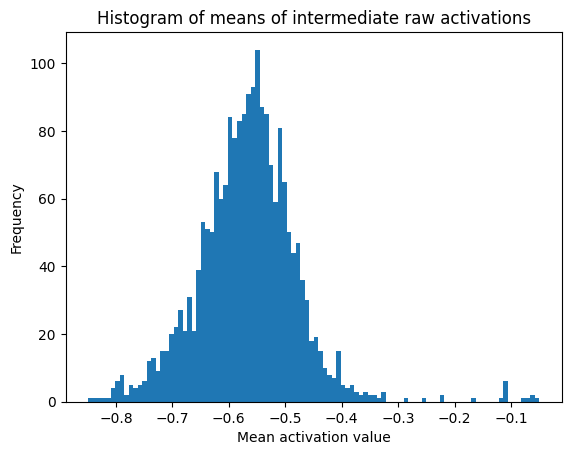

Mean and std of intermediate raw activations


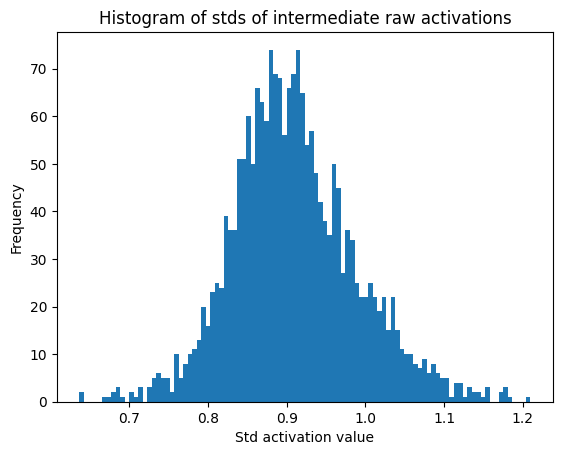

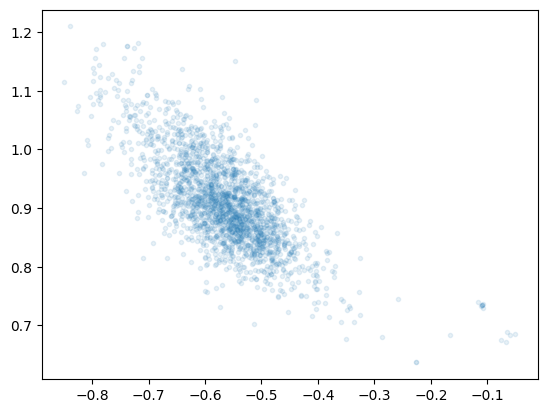

In [ ]:
with t.no_grad():
    intermediate_raw = submodule.dense_h_to_4h(x)
    means = t.mean(intermediate_raw, dim=1)
    stds = t.std(intermediate_raw, dim=1)
    plt.hist(means.cpu().numpy(), bins=100)
    plt.title('Histogram of means of intermediate raw activations')
    plt.xlabel('Mean activation value')
    plt.ylabel('Frequency')
    plt.show()
    print('Mean and std of intermediate raw activations')
    plt.hist(stds.cpu().numpy(), bins=100)
    plt.title('Histogram of stds of intermediate raw activations')
    plt.xlabel('Std activation value')
    plt.ylabel('Frequency')
    plt.show()
    plt.scatter(means.cpu().numpy(), stds.cpu().numpy(), marker='.', alpha=0.1)
    # print(means.mean().item(), means.std().item())
    # for i in range(10):
    #     print('Mean and std of intermediate raw activations for sample', i)
    #     print(t.mean(intermediate_raw[i,:]).item(), t.std(intermediate_raw[i,:]).item())
    #     # plt.hist(intermediate_raw[i,:].cpu().numpy(), bins=100)
    #     # plt.title('Histogram of intermediate raw activations')
    #     # plt.xlabel('Activation value')
    #     # plt.ylabel('Frequency')
    #     # plt.show()